# Example climb: different distributions with same mean

## 1. Notebook setup

### 1.1. Imports


In [1]:
import pickle
import sys
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

sys.path.append('..')

from hill_climber import HillClimber

### 1.2. Run configuration

In [2]:
# Set random seed for reproducibility
np.random.seed(315)

# Filename for results checkpoint
output_file = '../data/mean_results.pkl'

# Set True to re-run optimization, False to load checkpoint from disk
run_optimization = False

### 1.2. Input distributions

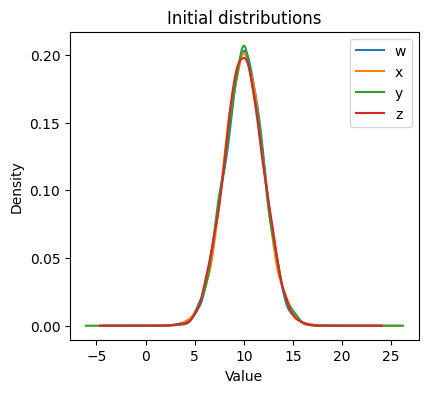

In [3]:
# Create input distributions (4 variables, all strictly positive)
# Start with similar normal distributions that will be evolved into different structures
n = 5000

data = pd.DataFrame({
    'w': np.random.normal(loc=10.0, scale=2.0, size=n),
    'x': np.random.normal(loc=10.0, scale=2.0, size=n),
    'y': np.random.normal(loc=10.0, scale=2.0, size=n),
    'z': np.random.normal(loc=10.0, scale=2.0, size=n)
})

# Ensure all values are strictly positive by clipping any negative values
for col in data.columns:
    data[col] = np.maximum(data[col], 0.1)  # Minimum value of 0.1

# Visualize using KDE plots to show initial distribution shapes
fig, ax = plt.subplots(figsize=(4.5,4))

plt.title('Initial distributions')

for col in data.columns:
    data[col].plot.kde(label=col, ax=ax)

plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

## 2. Optimization

### 2.1. Objective function

**Objective**: Wasserstein distance - ave(difference in means) * weight

In [4]:
def objective_similar_means_diverse_structures(w, x, y, z):
    '''Maximize structural diversity while maintaining similar means.
    
    Objective function: mean_wasserstein_distance - penalty_weight * mean_penalty
    
    This encourages:
        - Similar means across all 4 distributions (w, x, y, z)
        - Maximum structural diversity between distributions (high pairwise Wasserstein distances)
    
    The objective constrains the first moment (mean) while maximizing shape differences.
    Uses Wasserstein distance (Earth Mover's Distance) which is more sensitive to 
    distributional differences throughout the entire range compared to KS statistic.
    
    Args:
        w, x, y, z: Four variables (array-like)
    
    Returns:
        Tuple of (metrics_dict, objective_value) where:
            - metrics_dict: Dict with means, Wasserstein distances, and penalties
            - objective_value: mean_wasserstein_distance - penalty_weight * mean_penalty
    '''
    
    # Calculate means for all 4 distributions
    means = {
        'w': np.mean(w),
        'x': np.mean(x), 
        'y': np.mean(y),
        'z': np.mean(z)
    }
    
    # Calculate target mean (average across all distributions)
    target_mean = np.mean(list(means.values()))
    
    # Calculate mean penalty - how far each mean is from the target
    mean_deviations = [abs(mean_val - target_mean) for mean_val in means.values()]
    mean_penalty = np.mean(mean_deviations)
    
    # Calculate pairwise Wasserstein distances to measure structural diversity
    distributions = {'w': w, 'x': x, 'y': y, 'z': z}
    wasserstein_distances = {}
    wasserstein_values = []
    
    for name1, name2 in combinations(distributions.keys(), 2):

        w_dist = stats.wasserstein_distance(distributions[name1], distributions[name2])
        wasserstein_distances[f'Wasserstein_{name1}_{name2}'] = w_dist
        wasserstein_values.append(w_dist)
    
    # Mean Wasserstein distance - higher means more structural diversity
    mean_wasserstein = np.mean(wasserstein_values)
    
    # Objective: maximize structural diversity while maintaining similar means
    penalty_weight = 2
    objective = mean_wasserstein - (penalty_weight * mean_penalty)
    
    # Compile metrics
    metrics = {
        'Mean penalty': mean_penalty,
        'Mean wasserstein': mean_wasserstein
    }
    
    return metrics, objective

### 2.2. Hill climbing run

In [5]:
if run_optimization:

    # Create HillClimber instance
    climber = HillClimber(
        data=data,
        objective_func=objective_similar_means_diverse_structures,
        initial_step_spread=0.50,
        final_step_spread=0.05,
        perturb_fraction=0.02,
        T_min=1e-4,
        T_max=1,
        cooling_rate=5e-2,
        exchange_interval=1000,
        max_time=5,
        n_replicas=10,
        db_path='../data/means.db'
    )

    # Run optimization 
    best_data_df = climber.climb()

    # Save checkpoint after completion
    climber.checkpoint_file = output_file
    climber.save_checkpoint(output_file)

### 2.3. Results

In [11]:
# If we just re-ran the optimization, collect results from the climber
if run_optimization:
    replicates = climber.get_replicas()

# Otherwise, load from saved results
else:

    # Load the results checkpoint
    try:
        with open(output_file, 'rb') as f:
            results = pickle.load(f)

        # Get the winning replica's best data
        best_replica = max(results['replicas'], key=lambda r: r['best_objective'])

        best_data_df = pd.DataFrame(
            best_replica['best_data'],
            columns=data.columns
        )

        # Collect best data from each replica
        replicas = []

        for replica_data in results['replicas']:
            replica_df = pd.DataFrame(
                replica_data['best_data'],
                columns=data.columns
            )
            replicas.append(replica_df)

    except FileNotFoundError:
        print(f'Error: checkpoint file not found. Please run the optimization by setting run_optimization = True in the run configuration cell.')
    
        results_df = pd.DataFrame()

best_data_df.head()

,w,x,y,z
0,10.059323,15.988766,4.755988,15.151488
1,16.828147,5.005801,2.793514,9.627268
2,7.096720,17.390708,17.856924,3.185950
3,9.206889,15.805595,17.096288,13.620823
4,11.582681,4.195536,17.210309,4.839729


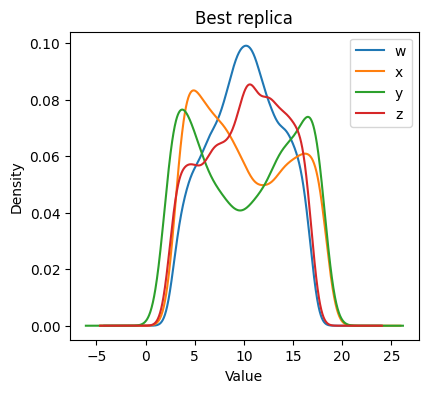

In [12]:
fig, ax = plt.subplots(figsize=(4.5,4))

plt.title('Best replica')

for col in best_data_df.columns:
    best_data_df[col].plot.kde(label=col, ax=ax)

plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

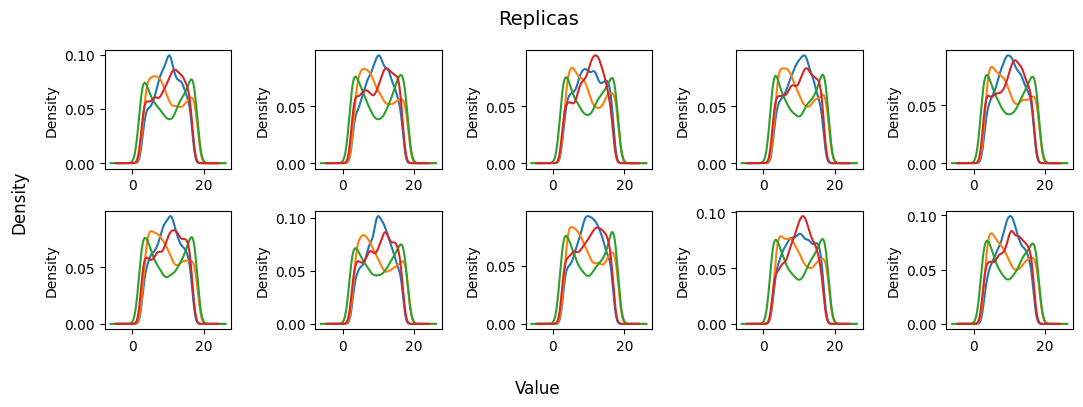

In [13]:
ncols = 5
nrows = len(replicas) // ncols

if len(replicas) % ncols != 0:
    nrows+=1

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2.2, nrows*2.0))
axs = axs.flatten()

fig.suptitle('Replicas', fontsize=14)
fig.supxlabel('Value', fontsize=12)
fig.supylabel('Density', fontsize=12)

for i, replica in enumerate(replicas):

    for col in replica.columns:
        replica[col].plot.kde(label=col, ax=axs[i])

plt.tight_layout()
plt.show()